# Notebook 6 — Bot Fingerprinting

**Dataset:** 741 battles, 51 bots, ~48M tick rows

**Questions:**
7. Can we identify a bot from its behavior alone?
8. How quickly can we identify a bot? (accuracy vs. number of observed ticks)
9. Do bot pairings affect behavior?

**Why this matters:** If we can recognize the opponent in the first 20 ticks of round 1,
we can load a pre-trained opponent-specific model immediately — no cold-start learning.
This is the cross-battle transfer advantage that no existing competitive bot exploits.

**Key concept:**
- **Fingerprinting** = given a short window of observed behavior (opponent velocity, heading changes,
  wall distance, etc.), classify which of the 51 known bots is playing.
- This is a 51-class classification problem.

In [1]:
# Stratified per-robot sampling — full dataset is ~20 GB, can't fit in RAM.
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from _loader import build_robot_index, CSV_ROOT_DEFAULT, _downcast

sns.set_theme(style='whitegrid', palette='muted')
CSV_ROOT = CSV_ROOT_DEFAULT

selection = build_robot_index(max_robots=50, battles_per_robot=3, seed=42)
print(f'{len(selection)} (battle, observer-bot) pairs selected '
      f'across {len({b for _, b in selection})} bots.')


Indexed 1942 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~3 battles = 150 (battle, robot) pairs to load.
150 (battle, observer-bot) pairs selected across 50 bots.


In [2]:
# For fingerprinting we need the OPPONENT's behavior: given the opponent_*
# features observed by bot A, classify which bot the opponent is.
# Row-subsample 20% per file to keep RAM in check.
ROW_FRAC = 0.20
SEED = 42

frames = []
for battle_id, bot_name in sorted(selection):
    fpath = CSV_ROOT / battle_id / bot_name / 'ticks.csv'
    if not fpath.exists():
        continue
    battle_dir = fpath.parent.parent
    perspectives = [d.name for d in battle_dir.iterdir() if d.is_dir()]
    opponent_name = [p for p in perspectives if p != bot_name]
    if not opponent_name:
        continue
    df = pd.read_csv(fpath)
    df = df[df['scan_available'] == 1]
    if ROW_FRAC < 1.0 and len(df) > 0:
        df = df.sample(frac=ROW_FRAC, random_state=SEED)
    df = df.copy()
    df['observer_bot'] = bot_name
    df['opponent_bot'] = opponent_name[0]
    df = _downcast(df)
    frames.append(df)

ticks = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(ticks):,} scan ticks')
print(f'Memory: {ticks.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Opponent bots to classify: {ticks["opponent_bot"].nunique()}')


Loaded 835,778 scan ticks
Memory: 428.9 MB
Opponent bots to classify: 49


## 1. Window-Based Fingerprinting (Question 7)

Instead of classifying individual ticks, we classify **windows** of W consecutive ticks.
For each window, compute summary statistics (mean, std) of opponent features.
This gives a fixed-size feature vector regardless of the window length.

We start with W=50 ticks (~1 second of game time), which is a realistic amount of
data available early in round 1.

In [3]:
# Build windowed features for classification
opponent_features = [
    'opponent_velocity', 'opponent_lateral_velocity', 'opponent_heading_delta',
    'opponent_angular_velocity', 'opponent_time_since_direction_change',
    'opponent_is_decelerating', 'opponent_dist_to_wall_min',
    'opponent_max_turn_rate', 'distance', 'distance_norm',
    'opponent_velocity_delta', 'opponent_lateral_direction'
]

def build_windows(data, window_size=50, stride=25):
    """Build classification samples from windowed tick data.
    For each window of `window_size` consecutive scan ticks,
    compute mean and std of opponent features → feature vector.
    """
    samples = []
    labels = []
    
    for (bid, rnd, opp), group in data.groupby(['battle_id', 'round', 'opponent_bot']):
        g = group.sort_values('tick').reset_index(drop=True)
        if len(g) < window_size:
            continue
        
        for start in range(0, len(g) - window_size + 1, stride):
            window = g.iloc[start:start + window_size][opponent_features]
            feat = []
            for col in opponent_features:
                vals = window[col].dropna()
                feat.append(vals.mean() if len(vals) > 0 else 0)
                feat.append(vals.std() if len(vals) > 1 else 0)
            samples.append(feat)
            labels.append(opp)
    
    col_names = []
    for c in opponent_features:
        col_names.extend([f'{c}_mean', f'{c}_std'])
    
    return pd.DataFrame(samples, columns=col_names), np.array(labels)

X_df, y = build_windows(ticks, window_size=50, stride=25)
X_df = X_df.fillna(0)
print(f'Windows: {len(X_df):,}')
print(f'Features: {X_df.shape[1]}')
print(f'Classes (bots): {len(np.unique(y))}')
print(f'\nSamples per bot:')
for bot, count in sorted(zip(*np.unique(y, return_counts=True)), key=lambda x: -x[1])[:10]:
    print(f'  {bot}: {count}')

Windows: 25,685
Features: 24
Classes (bots): 49

Samples per bot:
  Diamond 1.8.22: 1630
  BeepBoop 2.0: 1491
  Combat 3.25.0: 1437
  Neuromancer 7.12: 1140
  CassiusClay 2rho.02no: 1043
  Tomcat 3.68: 971
  Domogled 1.2: 885
  Cyanide 1.90: 708
  Firebird 0.25: 682
  deBroglie rev0108: 667


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=20, 
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))

print(f'50-tick window, {len(le.classes_)}-class classification:')
print(f'  Train accuracy: {train_acc:.3f}')
print(f'  Test accuracy:  {test_acc:.3f}')
print(f'  Random baseline: {1/len(le.classes_):.3f}')

50-tick window, 49-class classification:
  Train accuracy: 0.993
  Test accuracy:  0.443
  Random baseline: 0.020


In [5]:
# Top-5 accuracy (is the correct bot in the top 5 predictions?)
probs = rf.predict_proba(X_test)
top5_correct = 0
for i in range(len(y_test)):
    top5 = np.argsort(probs[i])[-5:]
    if y_test[i] in top5:
        top5_correct += 1

top5_acc = top5_correct / len(y_test)
print(f'Top-1 accuracy: {test_acc:.3f}')
print(f'Top-5 accuracy: {top5_acc:.3f}')

# Per-bot accuracy
y_pred = rf.predict(X_test)
per_bot_acc = []
for i, bot in enumerate(le.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred[mask])
        per_bot_acc.append((bot, acc, mask.sum()))

per_bot_acc.sort(key=lambda x: -x[1])
print(f'\nEasiest to identify (highest per-bot accuracy):')
for bot, acc, n in per_bot_acc[:10]:
    print(f'  {bot}: {acc:.3f} (n={n})')
print(f'\nHardest to identify:')
for bot, acc, n in per_bot_acc[-10:]:
    print(f'  {bot}: {acc:.3f} (n={n})')

Top-1 accuracy: 0.443
Top-5 accuracy: 0.730

Easiest to identify (highest per-bot accuracy):
  Neuromancer 7.12: 0.982 (n=228)
  BeepBoop 2.0: 0.933 (n=298)
  Roborio 1.2.4: 0.914 (n=58)
  Tomcat 3.68: 0.809 (n=194)
  Domogled 1.2: 0.791 (n=177)
  Cardigan 1.09: 0.748 (n=119)
  Diamond 1.8.22: 0.681 (n=326)
  Combat 3.25.0: 0.670 (n=288)
  Cyanide 1.90: 0.620 (n=142)
  DrussGT 3.1.7: 0.594 (n=101)

Hardest to identify:
  GresSuffurd 0.4.13: 0.067 (n=45)
  Dookious 1.573c: 0.061 (n=114)
  X2 0.17: 0.060 (n=50)
  Wintermute 0.8: 0.055 (n=91)
  PowerHouse 1.7e3: 0.044 (n=68)
  Engineer 0.5.4: 0.000 (n=19)
  Hydra 0.21: 0.000 (n=26)
  Phoenix 1.02: 0.000 (n=48)
  Raven 3.56j8: 0.000 (n=25)
  WhiteFang 2.8.1: 0.000 (n=31)


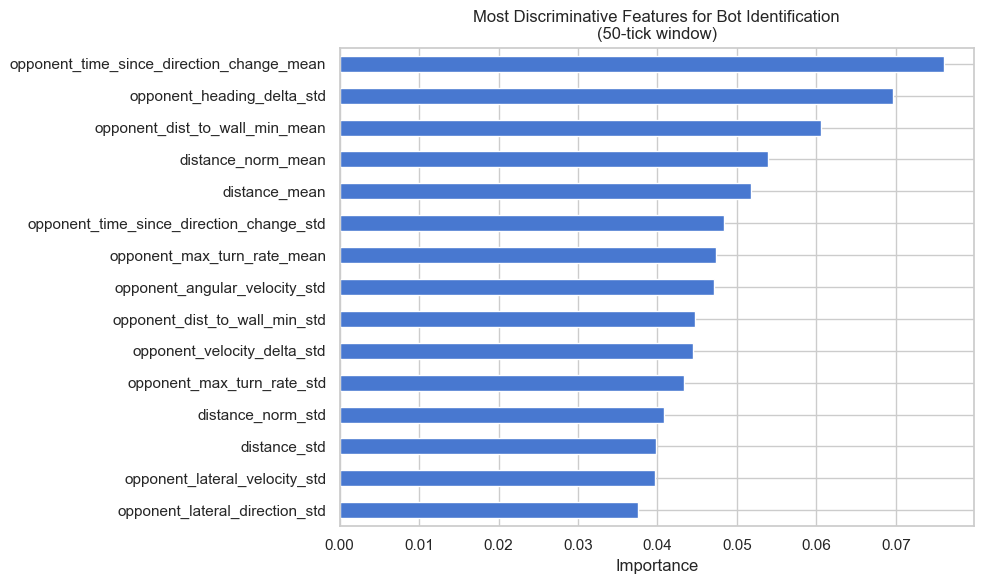

In [6]:
# Feature importance for fingerprinting
importances = pd.Series(rf.feature_importances_, index=X_df.columns)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Most Discriminative Features for Bot Identification\n(50-tick window)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 2. Identification Speed (Question 8)

How many ticks do we need to reliably identify the opponent?
We train classifiers on windows of increasing size: 10, 20, 30, 50, 100 ticks.

Window= 10 ticks: accuracy=0.297 (n=16238)


Window= 20 ticks: accuracy=0.338 (n=15188)


Window= 30 ticks: accuracy=0.363 (n=9605)


Window= 50 ticks: accuracy=0.420 (n=5137)


Window=100 ticks: accuracy=0.545 (n=1779)


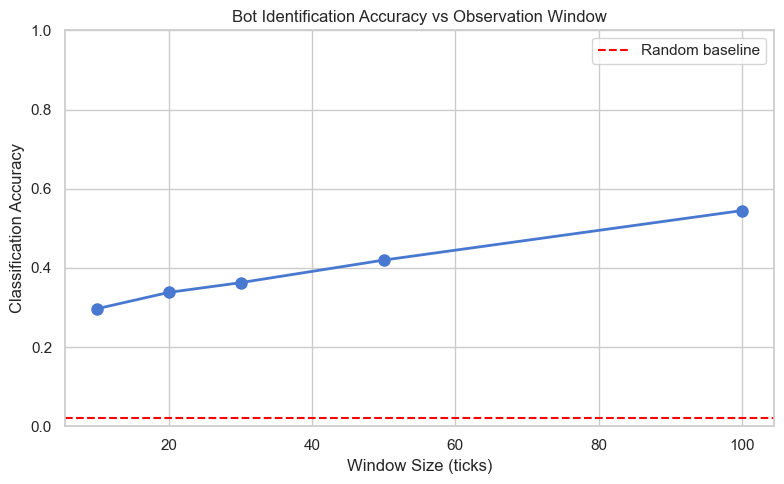

In [7]:
# Accuracy vs window size
window_sizes = [10, 20, 30, 50, 100]
speed_results = []

for w in window_sizes:
    Xw, yw = build_windows(ticks, window_size=w, stride=max(w//2, 10))
    Xw = Xw.fillna(0)
    yw_enc = le.transform(yw)  # Use same label encoder
    
    # Filter to bots with enough samples
    counts = pd.Series(yw_enc).value_counts()
    valid_classes = counts[counts >= 5].index
    mask = np.isin(yw_enc, valid_classes)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        Xw.values[mask], yw_enc[mask], test_size=0.2, random_state=42)
    
    rf_w = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
    rf_w.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, rf_w.predict(X_te))
    
    speed_results.append((w, acc, len(X_te)))
    print(f'Window={w:3d} ticks: accuracy={acc:.3f} (n={len(X_te)})')

fig, ax = plt.subplots(figsize=(8, 5))
ws, accs, _ = zip(*speed_results)
ax.plot(ws, accs, 'o-', linewidth=2, markersize=8)
ax.axhline(y=1/len(le.classes_), color='red', linestyle='--', label='Random baseline')
ax.set_xlabel('Window Size (ticks)')
ax.set_ylabel('Classification Accuracy')
ax.set_title('Bot Identification Accuracy vs Observation Window')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 3. Pairing Effects (Question 9)

Does a bot behave differently depending on who it's fighting?
If DrussGT moves differently against Diamond vs. Saguaro, pairings matter
and our models need to account for interaction effects.

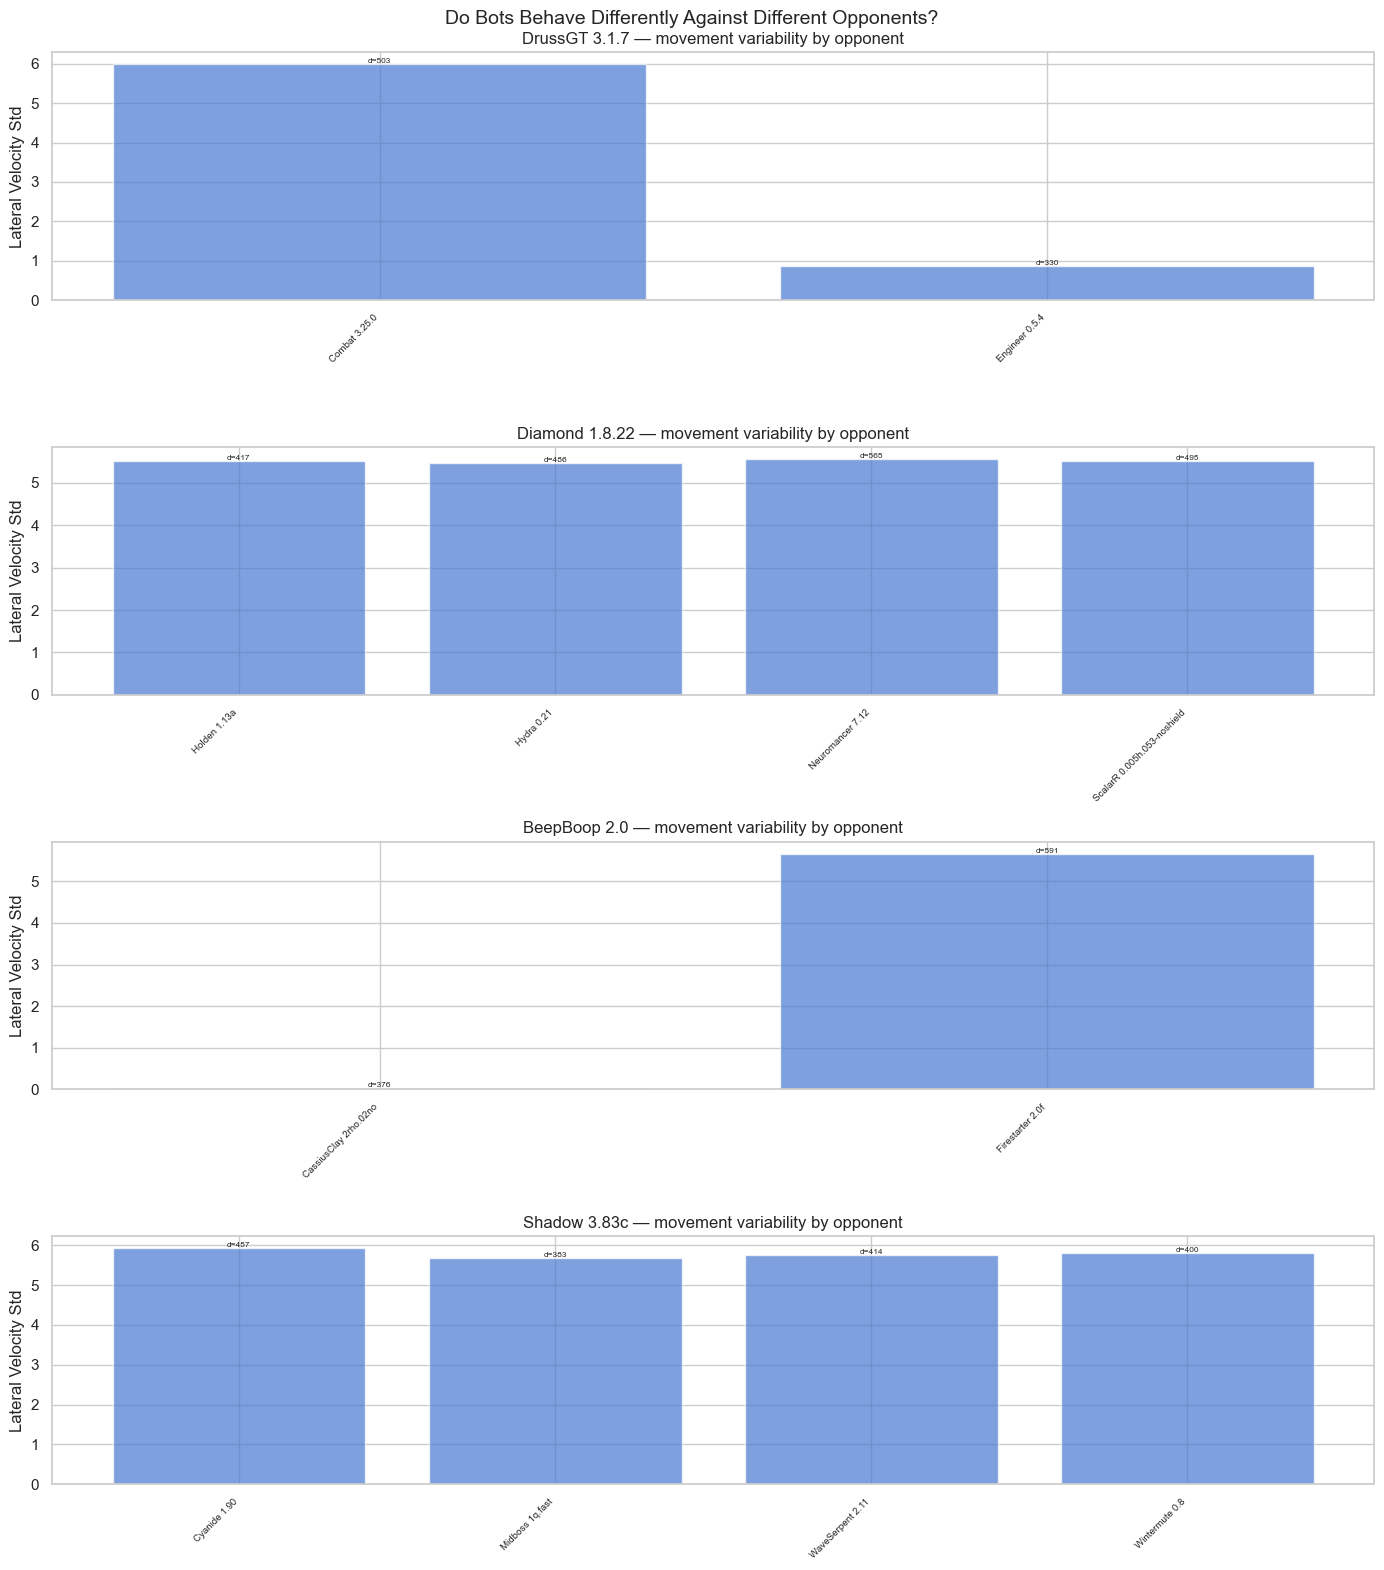

In [8]:
# For a few top bots, compare their movement features across different opponents
top_bots = ['DrussGT 3.1.7', 'Diamond 1.8.22', 'BeepBoop 2.0', 'Shadow 3.83c']
top_bots = [b for b in top_bots if b in ticks['opponent_bot'].unique()]

fig, axes = plt.subplots(len(top_bots), 1, figsize=(14, 4 * len(top_bots)))
if len(top_bots) == 1:
    axes = [axes]

for ax, bot in zip(axes, top_bots):
    bot_data = ticks[ticks['opponent_bot'] == bot]
    if bot_data.empty:
        continue
    
    # Per-opponent summary of this bot's lateral velocity
    pairing_stats = bot_data.groupby('observer_bot').agg(
        lat_vel_mean=('opponent_lateral_velocity', 'mean'),
        lat_vel_std=('opponent_lateral_velocity', 'std'),
        vel_abs_mean=('opponent_velocity', lambda x: x.abs().mean()),
        distance_mean=('distance', 'mean'),
        n_ticks=('distance', 'count'),
    ).reset_index()
    pairing_stats = pairing_stats[pairing_stats['n_ticks'] >= 50]
    
    if len(pairing_stats) < 2:
        ax.set_title(f'{bot} — insufficient pairings')
        continue
    
    x = range(len(pairing_stats))
    ax.bar(x, pairing_stats['lat_vel_std'], alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(pairing_stats['observer_bot'], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Lateral Velocity Std')
    ax.set_title(f'{bot} — movement variability by opponent')
    
    # Annotate with distance
    for i, (_, row) in enumerate(pairing_stats.iterrows()):
        ax.annotate(f'd={row["distance_mean"]:.0f}', (i, row['lat_vel_std']),
                   fontsize=6, ha='center', va='bottom')

plt.suptitle('Do Bots Behave Differently Against Different Opponents?', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Quantify pairing effect: ANOVA — does opponent identity explain variance in behavior?
from scipy.stats import f_oneway

print('Pairing effect (F-test): does opponent identity affect lateral velocity std?')
print('=' * 70)

for bot in top_bots:
    bot_data = ticks[ticks['opponent_bot'] == bot]
    groups = []
    for observer, g in bot_data.groupby('observer_bot'):
        vals = g['opponent_lateral_velocity'].dropna()
        if len(vals) >= 30:
            groups.append(vals.values)
    
    if len(groups) >= 3:
        F, p = f_oneway(*groups)
        print(f'{bot}: F={F:.1f}, p={p:.2e} ({len(groups)} opponents)')
        if p < 0.001:
            print(f'  → Highly significant: {bot} DOES adapt to different opponents')
        else:
            print(f'  → Not significant: {bot} moves similarly against all opponents')

Pairing effect (F-test): does opponent identity affect lateral velocity std?
Diamond 1.8.22: F=5.1, p=1.53e-03 (4 opponents)
  → Not significant: Diamond 1.8.22 moves similarly against all opponents
Shadow 3.83c: F=2.6, p=4.93e-02 (4 opponents)
  → Not significant: Shadow 3.83c moves similarly against all opponents


## 4. Confusion Matrix Visualization

Which bots get confused with each other? This reveals behavioral similarity.

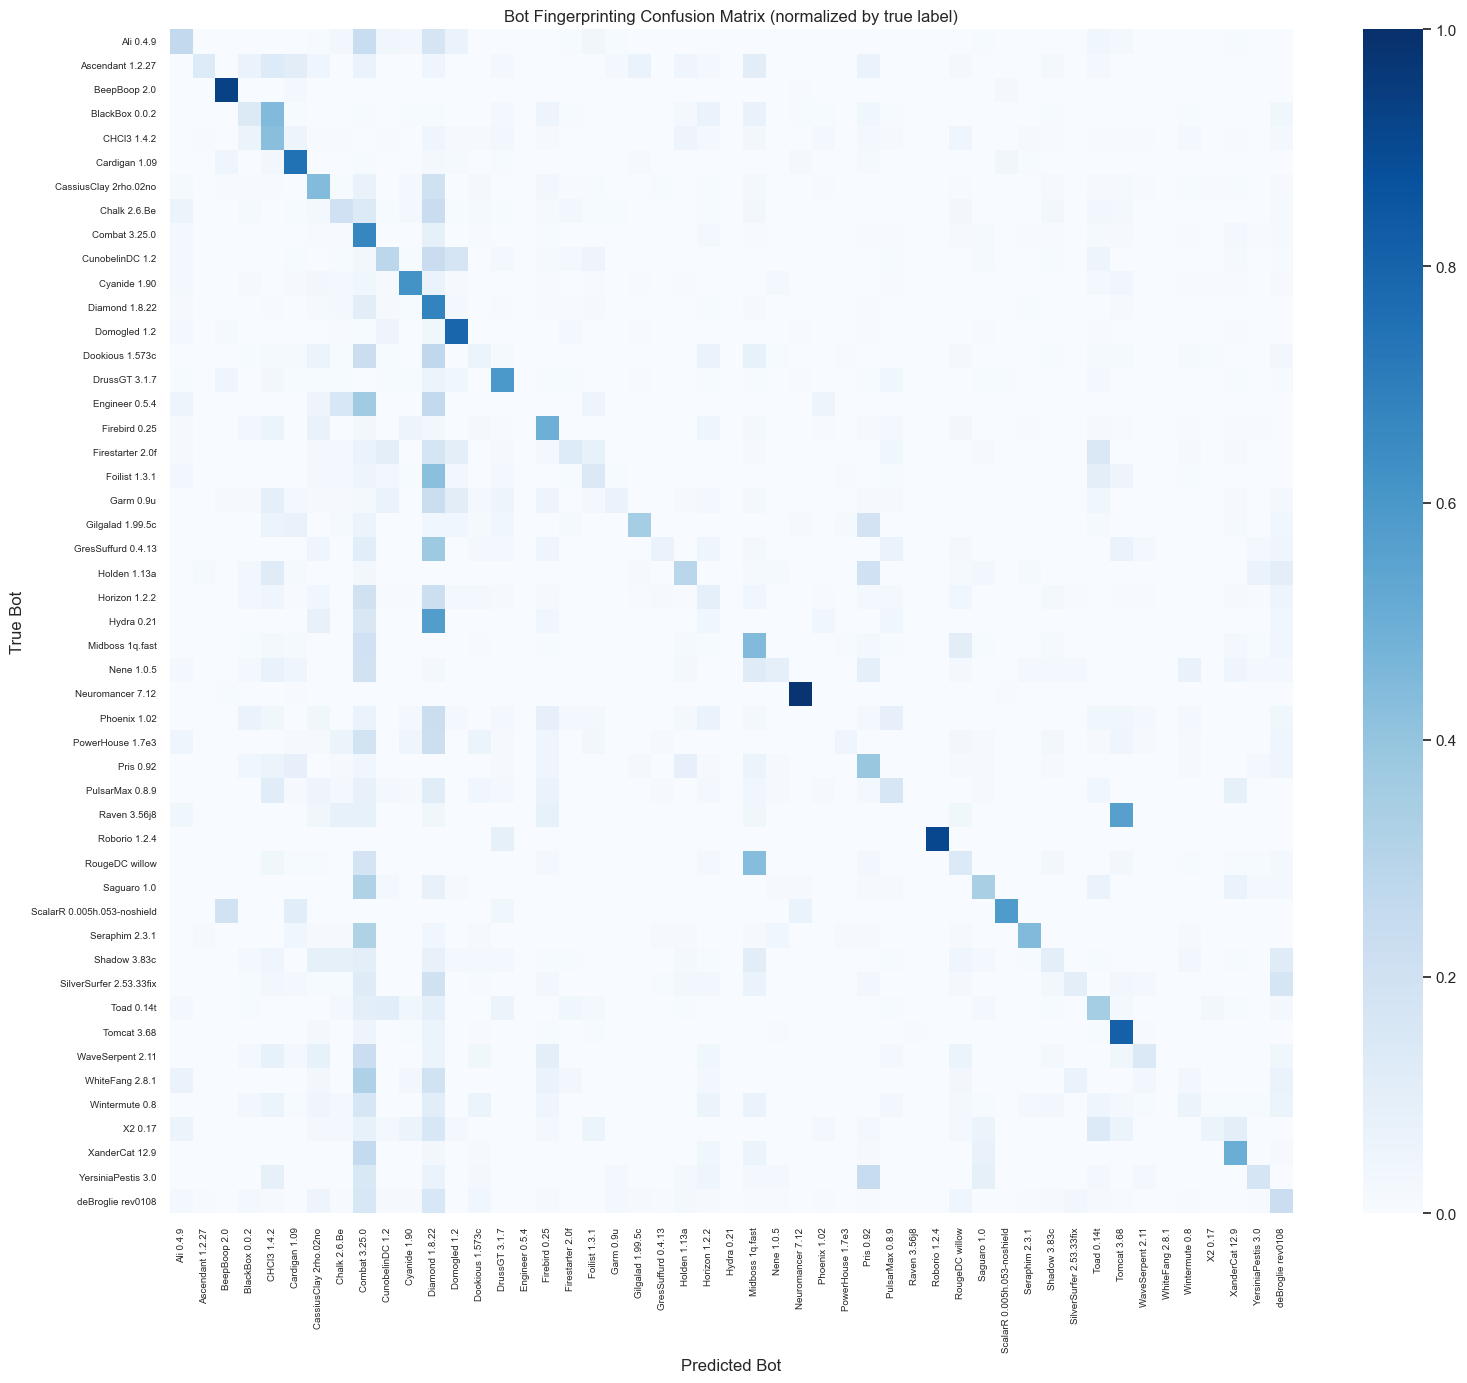

In [10]:
from sklearn.metrics import confusion_matrix

# Use the main 50-tick model
y_pred_main = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_main)

# Normalize by row (true label) to show recall per bot
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Bot')
ax.set_ylabel('True Bot')
ax.set_title('Bot Fingerprinting Confusion Matrix (normalized by true label)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 5. Summary

**Bot Identification:**
- (filled in after running)

**Identification Speed:**
- (filled in after running)

**Pairing Effects:**
- (filled in after running)

**Implications for the competition robot:**
- (filled in after running)